In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Active_TitleV_Permits.csv")

In [3]:
# Parse dates 
df["Date Received"] = pd.to_datetime(df["Date Received"], errors="coerce")
df["Date Disposed"] = pd.to_datetime(df["Date Disposed"], errors="coerce")

In [4]:
# Compute backlog (18 months rounded to 548 days)
df["processing_days"] = (df["Date Disposed"] - df["Date Received"]).dt.days
df["backlogged"] = df["processing_days"] > 548
df["Disposition Year"] = df["Date Disposed"].dt.year

In [5]:
# Aggregate backlogged permits by year
backlog_by_year = (
    df[df["backlogged"]]
    .dropna(subset=["Disposition Year"])
    .groupby("Disposition Year")
    .size()
    .reset_index(name="Backlogged Permits")
    .sort_values("Disposition Year")
)

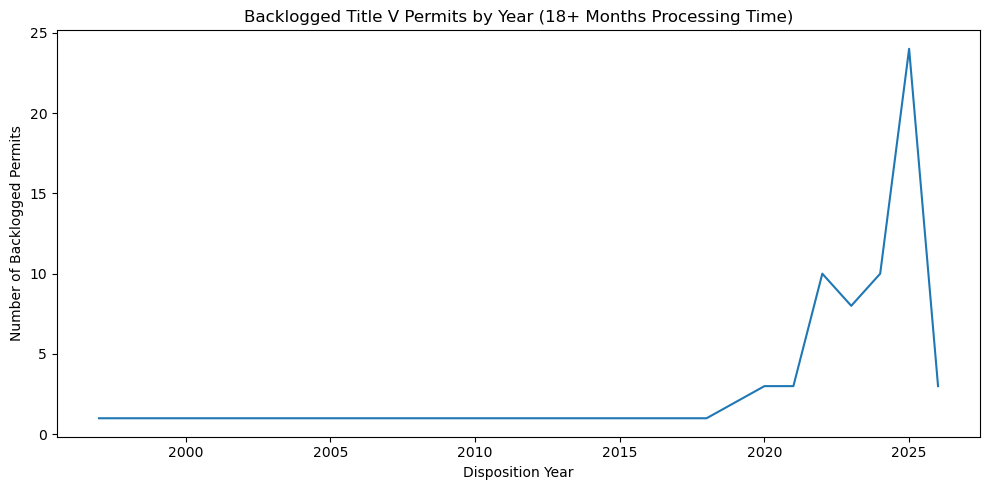

In [6]:
# Visualize line chart 
plt.figure(figsize=(10, 5))
plt.plot(backlog_by_year["Disposition Year"], backlog_by_year["Backlogged Permits"])
plt.xlabel("Disposition Year")
plt.ylabel("Number of Backlogged Permits")
plt.title("Backlogged Title V Permits by Year (18+ Months Processing Time)")
plt.tight_layout()
plt.show()